## Importing libraries

In [1]:
import scipy.stats as stats
from scipy import special
import scipy.special as sc
import numpy as np
from math import sqrt, log
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## General parameters

In [2]:
sample_value = 100000
tau = 5
sep = 0.001

prior_sigmas = {
    'Flat prior': 0
    ,'Jeffreys prior': 0.5
    ,'Scale-invariant prior': 1
}

prior_colors = {
    'Flat prior': 'green'
    ,'Jeffreys prior': 'orange'
    ,'Scale-invariant prior': 'blue'
}

np.random.seed(42)

## Definition of functions

In [3]:
def error_ci(p, alpha, sample_size):

    se = np.sqrt(p * (1 - p) / sample_size)
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    lower = p - z_alpha * se
    upper = p + z_alpha * se

    return lower, upper


def delta_ci(p1, p2, alpha, sample_size):

    se = np.sqrt(p1 * (1 - p1) / sample_size + p2 * (1 - p2) / sample_size)
    delta = p2 - p1
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    lower = delta - z_alpha * se
    upper = delta + z_alpha * se

    return lower, delta, upper


def pr_vect(N_on, N_off, tau, sigma):

    if sigma not in (0, 0.5, 1):
        raise ValueError('sigma must be equal to 0, 0.5, or 1')

    N_on = np.asarray(N_on)
    N_off = np.asarray(N_off)
    tau = np.asarray(tau, dtype=float)

    if tau.ndim < N_on.ndim:
        tau = tau[(...,) + (np.newaxis,) * (N_on.ndim - tau.ndim)]

    x = tau / (tau + 1.0)
    a = N_off + 1.0 - sigma
    b = N_on - sigma + 1.0

    valid = (a > 0) & (b > 0) & (tau >= 0)
    beta_vals = special.betainc(a, b, x)

    return np.where(valid, beta_vals, 0.0)


def S(N_on, N_off, tau):

    N_on = np.asarray(N_on)
    N_off = np.asarray(N_off)
    tau = np.asarray(tau, dtype=float)

    if tau.ndim < N_on.ndim:
        tau = tau[(...,) + (np.newaxis,) * (N_on.ndim - tau.ndim)]

    with np.errstate(divide='ignore', invalid='ignore'):
        x = (N_on * np.log((1 + tau) * N_on / (N_on + N_off)) +
             N_off * np.log((1 + tau) * N_off / (tau * (N_on + N_off))))

        cond0 = (N_on == 0) & (N_off == 0)
        cond1 = N_on == 0
        cond2 = N_off == 0

        return np.where(
            cond0
            ,0.0
            ,np.where(
                cond1
                ,2 * N_off * np.log((1 + tau) / tau)
                ,np.where(
                    cond2
                    ,2 * N_on * np.log(1 + tau)
                    ,2 * x
                )
            )
        )


def pois_with_overdispersion(lam, theta, sample):

    if theta == 0:
        return np.random.poisson(lam, sample)
    else:
        r = 1 / theta

    p = 1 / (1 + theta * lam)

    return stats.nbinom(r, p).rvs(sample)

## Li and Ma approach

In [4]:
b = 20

a = list(np.arange(0, 1.001, sep))
a_arr = np.array(a)

non = np.random.poisson(b, (len(a), sample_value))
nof = np.random.poisson(b * tau, (len(a), sample_value))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)

error_type_1 = list(np.mean(p_value < a_arr[:, None], axis=1))

OLS linear approximation coefficients:  [0.99800786 0.00224037]
R square:  0.9998801256637728


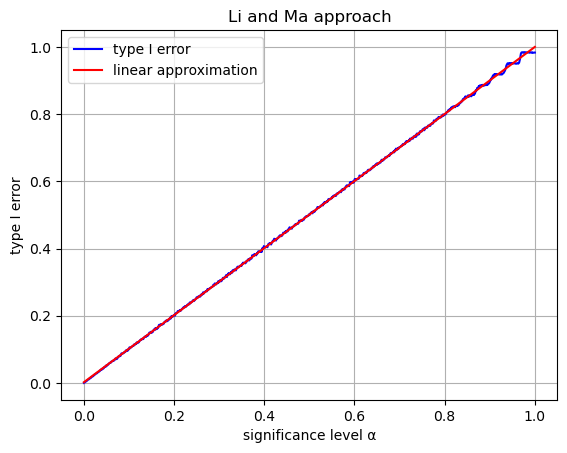

In [5]:
x = np.array(a)
y = np.array(error_type_1)

coefficients = np.polyfit(x, y, 1)
print("OLS linear approximation coefficients: ", coefficients)

y_pred = np.polyval(coefficients, x)
y_mean = np.mean(y)
SS_res = np.sum((y - y_pred) ** 2)
SS_tot = np.sum((y - y_mean) ** 2)
R2 = 1 - (SS_res / SS_tot)
print("R square: ", R2)

plt.plot(x, y, markersize=4, label='type I error', color = 'blue')
plt.plot(x, np.polyval(coefficients, x), label='linear approximation', color = 'red')
plt.xlabel('significance level α')
plt.ylabel('type I error')
plt.grid()
plt.title("Li and Ma approach")
plt.legend()
plt.show()

In [6]:
lam = list(np.arange(0, 201, 1))
lam_arr = np.array(lam)

non = np.random.poisson(lam_arr[:, None], (len(lam), sample_value))
nof = np.random.poisson(lam_arr[:, None] * tau, (len(lam), sample_value))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)

error_type_1 = list(np.mean(p_value < 0.05, axis=1))

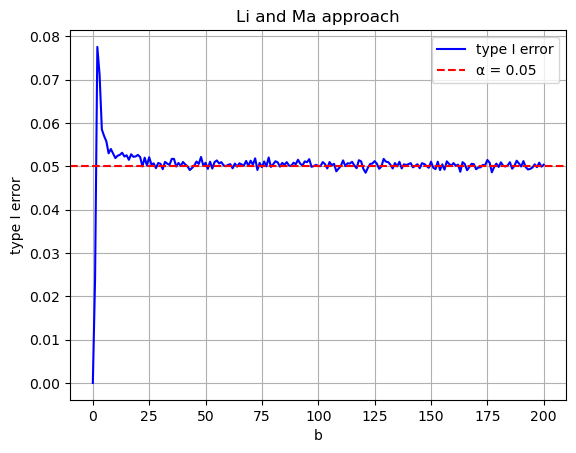

In [7]:
x = np.array(lam)
y = np.array(error_type_1)

plt.plot(x, y, label='type I error', markersize=4, color = 'blue')
plt.axhline(y=0.05, label='α = 0.05', color='red', linestyle='--')
plt.xlabel('b')
plt.ylabel('type I error')
plt.grid()
plt.legend()
plt.title('Li and Ma approach')
plt.show()

## Bayesian approach

In [8]:
b = 20

a = list(np.arange(0, 1.001, sep))
a_arr = np.array(a)

non = np.random.poisson(b, (len(a), sample_value))
nof = np.random.poisson(b * tau, (len(a), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

error_type_1_flat = list(np.mean(p_flat > 1 - a_arr[:, None], axis=1))
error_type_1_jeffreys = list(np.mean(p_jeffreys > 1 - a_arr[:, None], axis=1))
error_type_1_scale_invariant = list(np.mean(p_scale_invariant > 1 - a_arr[:, None], axis=1))

OLS linear approximation coefficients for Flat prior:  [1.00119214 0.02253856]
R square for Flat prior:  0.9989722900946697
OLS linear approximation coefficients for Jeffreys prior:  [9.98344531e-01 8.52779257e-04]
R square for Jeffreys prior:  0.9999537180368558
OLS linear approximation coefficients for Scale-invariant prior:  [ 0.99171094 -0.01902316]
R square for Scale-invariant prior:  0.9989735224379422


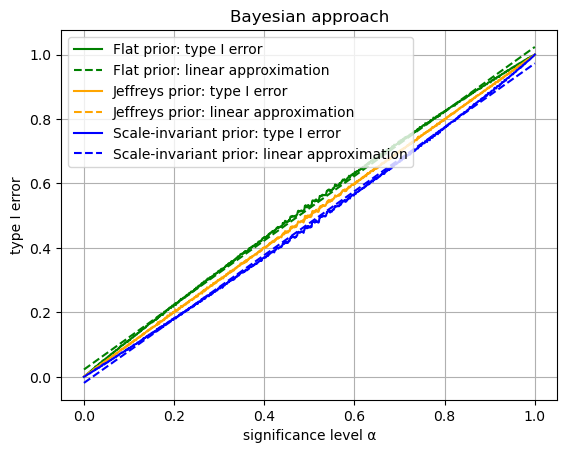

In [9]:
x = np.array(a)

for prior_name, error_type_1_prior in (
    ('Flat prior', error_type_1_flat)
    ,('Jeffreys prior', error_type_1_jeffreys)
    ,('Scale-invariant prior', error_type_1_scale_invariant)
):
    y = np.array(error_type_1_prior)

    coefficients = np.polyfit(x, y, 1)
    print(f"OLS linear approximation coefficients for {prior_name}: ", coefficients)

    y_pred = np.polyval(coefficients, x)
    y_mean = np.mean(y)
    SS_res = np.sum((y - y_pred) ** 2)
    SS_tot = np.sum((y - y_mean) ** 2)
    R2 = 1 - (SS_res / SS_tot)
    print(f"R square for {prior_name}: ", R2)

    plt.plot(x, y, markersize=4, label=f'{prior_name}: type I error', color=prior_colors[prior_name])
    plt.plot(x, np.polyval(coefficients, x), label=f'{prior_name}: linear approximation',
             color=prior_colors[prior_name], linestyle='--')

plt.xlabel('significance level α')
plt.ylabel('type I error')
plt.grid()
plt.title("Bayesian approach")
plt.legend()
plt.show()

In [10]:
lam = list(np.arange(0, 101, 1))
lam_arr = np.array(lam)

non = np.random.poisson(lam_arr[:, None], (len(lam), sample_value))
nof = np.random.poisson(lam_arr[:, None] * tau, (len(lam), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

error_type_1_flat = list(np.mean(p_flat > 0.95, axis=1))
error_type_1_jeffreys = list(np.mean(p_jeffreys > 0.95, axis=1))
error_type_1_scale_invariant = list(np.mean(p_scale_invariant > 0.95, axis=1))

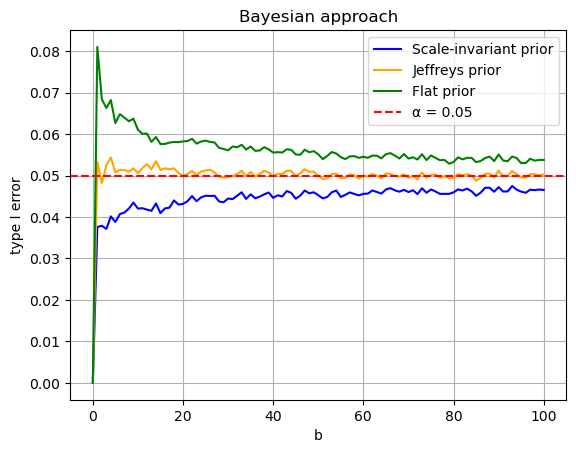

In [11]:
x = np.array(lam)
y1 = np.array(error_type_1_scale_invariant)
y2 = np.array(error_type_1_jeffreys)
y3 = np.array(error_type_1_flat)

plt.plot(x, y1, label='Scale-invariant prior', markersize=4, color='blue')
plt.plot(x, y2, label='Jeffreys prior', markersize=4, color='orange')
plt.plot(x, y3, label='Flat prior', markersize=4, color='green')
plt.axhline(y=0.05, label='α = 0.05', color='red', linestyle='--')
plt.xlabel('b')
plt.ylabel('type I error')
plt.grid()
plt.legend()
plt.title('Bayesian approach')
plt.show()

## Comparison of methods: type I error

In [12]:
lam = list(np.arange(0, 20.1, 0.1))
lam_arr = np.array(lam)

non = np.random.poisson(lam_arr[:, None], (len(lam), sample_value))
nof = np.random.poisson(lam_arr[:, None] * tau, (len(lam), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

error_type_1_flat = list(np.mean(p_flat > 0.95, axis=1))
error_type_1_jeffreys = list(np.mean(p_jeffreys > 0.95, axis=1))
error_type_1_scale_invariant = list(np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)

et_1 = list(np.mean(p_value < 0.05, axis=1))

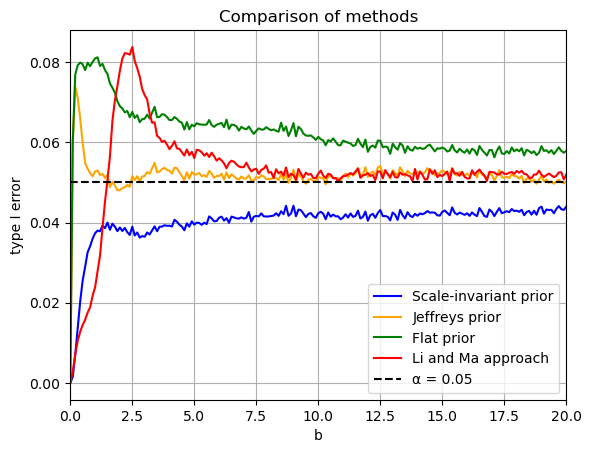

In [13]:
x = np.array(lam)
y1 = np.array(error_type_1_scale_invariant)
y2 = np.array(error_type_1_jeffreys)
y3 = np.array(error_type_1_flat)
y4 = np.array(et_1)

plt.plot(x, y1, markersize=4, label='Scale-invariant prior', color='blue')
plt.plot(x, y2, markersize=4, label='Jeffreys prior', color='orange')
plt.plot(x, y3, markersize=4, label='Flat prior', color='green')
plt.plot(x, y4, markersize=4, label='Li and Ma approach', color='red')
plt.axhline(y=0.05, label='α = 0.05', color='black', linestyle='--')

plt.xlabel('b')
plt.xlim(0, 20)
plt.ylabel('type I error')
plt.grid()
plt.title('Comparison of methods')
plt.legend()
plt.show()

In [14]:
lam = 40
tau_values = list(np.arange(1, 20.1, 0.1))
tau_arr = np.array(tau_values)

non = np.random.poisson(lam, (len(tau_values), sample_value))
nof = np.random.poisson(lam * tau_arr[:, None], (len(tau_values), sample_value))

p_flat = pr_vect(non, nof, tau_arr[:, None], sigma=0)
p_jeffreys = pr_vect(non, nof, tau_arr[:, None], sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau_arr[:, None], sigma=1)

et_1_flat = list(np.mean(p_flat > 0.95, axis=1))
et_1_jeffreys = list(np.mean(p_jeffreys > 0.95, axis=1))
et_1_scale_invariant = list(np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau_arr[:, None]), df=1)
et_1_W = list(np.mean(p_value < 0.05, axis=1))

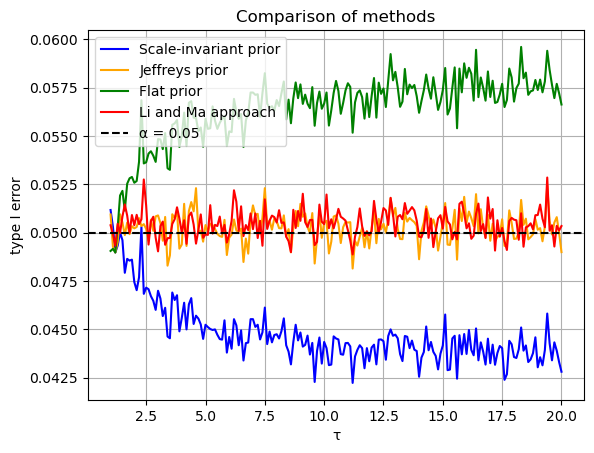

In [15]:
x = np.array(tau_values)
y1 = np.array(et_1_scale_invariant)
y2 = np.array(et_1_jeffreys)
y3 = np.array(et_1_flat)
y4 = np.array(et_1_W)

plt.plot(x, y1, markersize=4, label='Scale-invariant prior', color='blue')
plt.plot(x, y2, markersize=4, label='Jeffreys prior', color='orange')
plt.plot(x, y3, markersize=4, label='Flat prior', color='green')
plt.plot(x, y4, markersize=4, label='Li and Ma approach', color='red')
plt.axhline(y=0.05, label='α = 0.05', color='black', linestyle='--')

plt.xlabel('τ')
plt.ylabel('type I error')
plt.grid()
plt.title('Comparison of methods')
plt.legend()
plt.show()

In [80]:
lam = np.arange(0, 21, 1)
tau_values = np.arange(1, 101, 1)

lam_2d = lam[np.newaxis, :]
tau_2d = tau_values[:, np.newaxis]

mean_on  = np.broadcast_to(lam_2d, (len(tau_values), len(lam)))[..., np.newaxis]
mean_off = (lam_2d * tau_2d)[..., np.newaxis]

non = np.random.poisson(mean_on,  (len(tau_values), len(lam), sample_value))
nof = np.random.poisson(mean_off, (len(tau_values), len(lam), sample_value))

p_flat = pr_vect(non, nof, tau_2d, sigma=0)
p_jeffreys = pr_vect(non, nof, tau_2d, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau_2d, sigma=1)
S_values = S(non, nof, tau_2d)

cond_flat = p_flat > 0.95
cond_jeffreys = p_jeffreys > 0.95
cond_scale_invariant = p_scale_invariant > 0.95
p_value = 1 - stats.chi2.cdf(S_values, df=1)
cond_W = p_value < 0.05

error_matrix_flat = np.mean(cond_flat, axis=-1)
error_matrix_jeffreys = np.mean(cond_jeffreys, axis=-1)
error_matrix_scale_invariant = np.mean(cond_scale_invariant, axis=-1)
error_matrix_W = np.mean(cond_W, axis=-1)

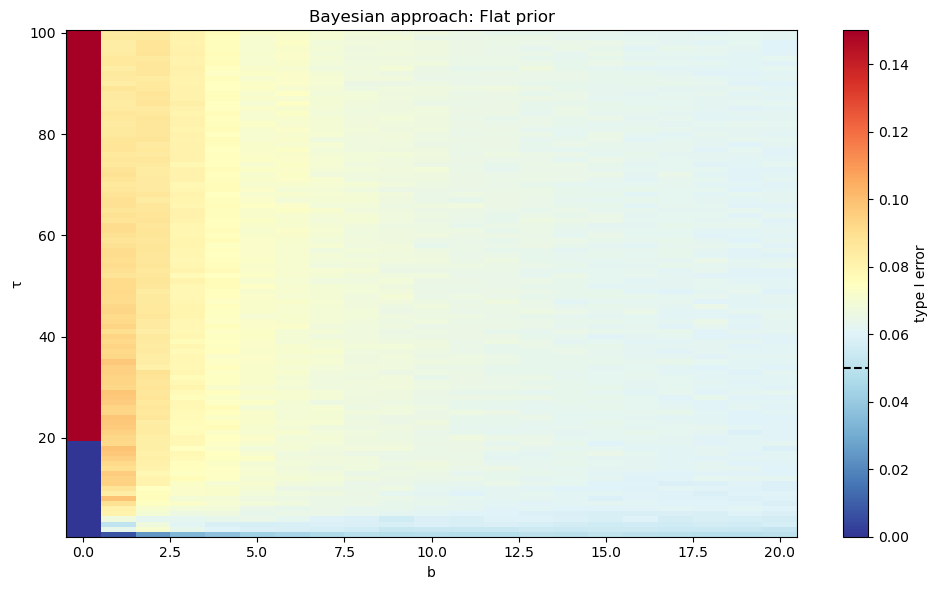

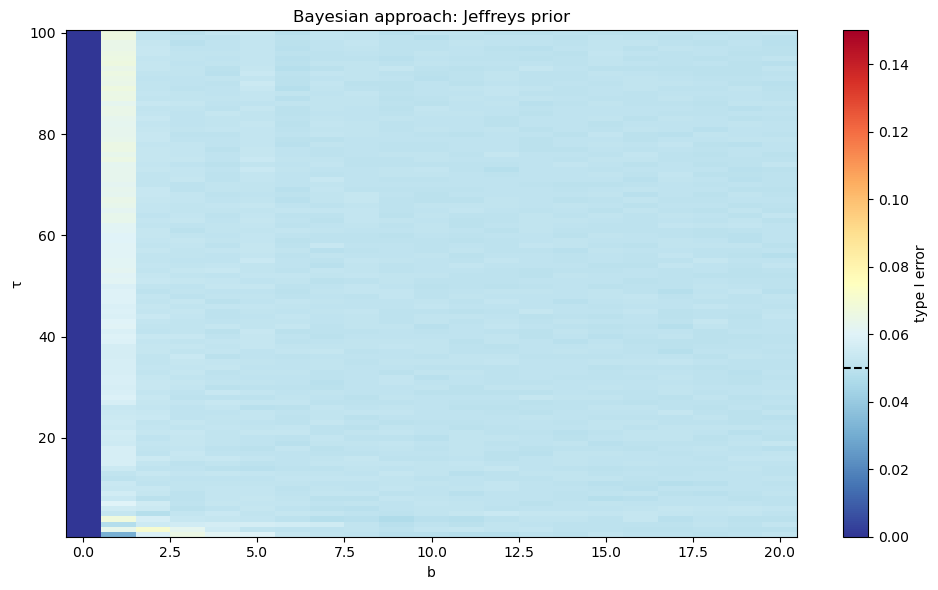

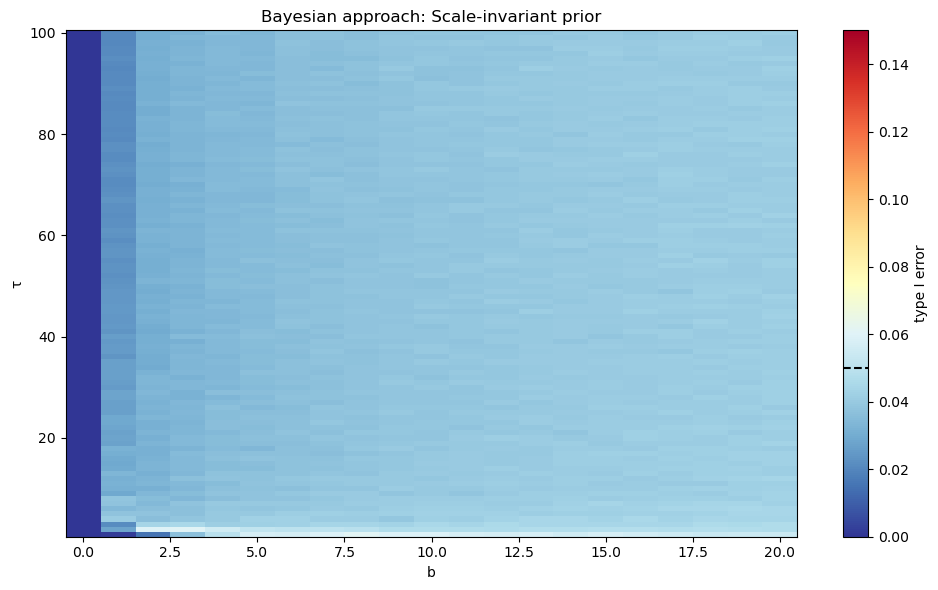

In [81]:
B_grid, Tau_grid = np.meshgrid(lam, tau_values)

for prior_name, error_matrix in (
    ('Flat prior', error_matrix_flat)
    ,('Jeffreys prior', error_matrix_jeffreys)
    ,('Scale-invariant prior', error_matrix_scale_invariant)
):
    fig, ax = plt.subplots(figsize=(10, 6))

    c = ax.pcolormesh(
        B_grid
        ,Tau_grid
        ,error_matrix
        ,cmap='RdYlBu_r'
        ,shading='nearest'
        ,vmin=0, vmax=0.15
    )

    cbar = plt.colorbar(c, ax=ax, label='type I error')
    cbar.ax.axhline(0.05, color='black', lw=1.5, linestyle='--')

    ax.set_xlabel('b')
    ax.set_ylabel('τ')
    ax.set_title(f'Bayesian approach: {prior_name}')

    plt.tight_layout()
    plt.show()

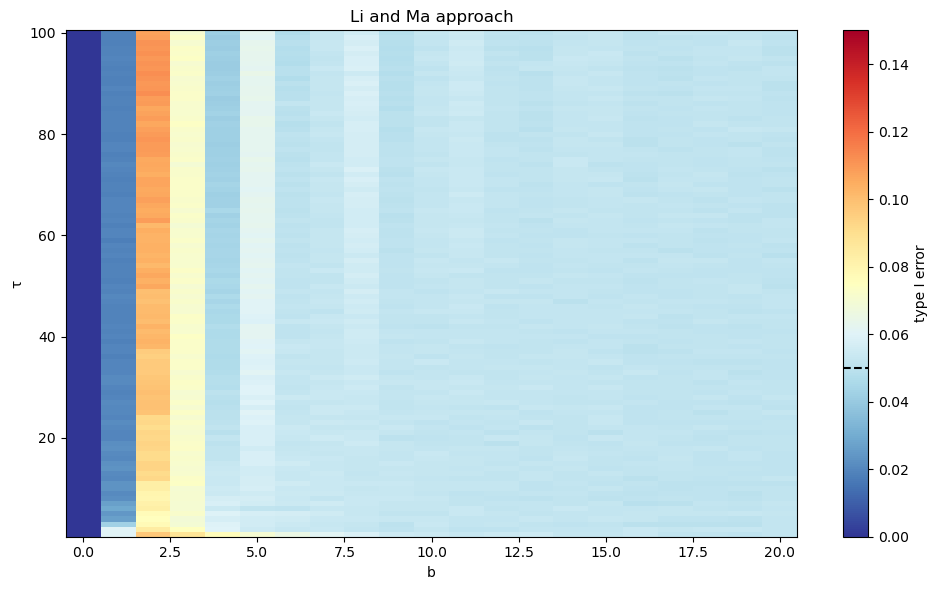

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

B_grid, Tau_grid = np.meshgrid(lam, tau_values)

c = ax.pcolormesh(
    B_grid
    ,Tau_grid
    ,error_matrix_W
    ,cmap='RdYlBu_r'
    ,shading='nearest'
    ,vmin=0, vmax=0.15
)

cbar = plt.colorbar(c, ax=ax, label='type I error')
cbar.ax.axhline(0.05, color='black', lw=1.5, linestyle='--')

ax.set_xlabel('b')
ax.set_ylabel('τ')
ax.set_title('Li and Ma approach')

plt.tight_layout()
plt.show()

In [83]:
lam  = np.arange(0, 101, 1)
N_on = np.arange(0, 21, 1)

lam_2d  = lam[np.newaxis, :]
N_on_2d = N_on[:, np.newaxis]

with np.errstate(divide='ignore', invalid='ignore'):
    tau_2d = lam_2d / N_on_2d
valid_param = (N_on_2d > 0) & (N_on_2d <= lam_2d)

mean_on  = np.broadcast_to(N_on_2d, (len(N_on), len(lam)))[..., np.newaxis]
mean_off = np.broadcast_to(lam_2d,  (len(N_on), len(lam)))[..., np.newaxis]

non = np.random.poisson(mean_on,  (len(N_on), len(lam), sample_value))
nof = np.random.poisson(mean_off, (len(N_on), len(lam), sample_value))

p_flat = pr_vect(non, nof, tau_2d, sigma=0)
p_jeffreys = pr_vect(non, nof, tau_2d, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau_2d, sigma=1)
S_values = S(non, nof, tau_2d)

cond_flat = p_flat > 0.95
cond_jeffreys = p_jeffreys > 0.95
cond_scale_invariant = p_scale_invariant > 0.95
p_value = 1 - stats.chi2.cdf(S_values, df=1)
cond_W = p_value < 0.05

error_matrix_flat = np.where(valid_param, np.mean(cond_flat, axis=-1), np.nan)
error_matrix_jeffreys = np.where(valid_param, np.mean(cond_jeffreys, axis=-1), np.nan)
error_matrix_scale_invariant = np.where(valid_param, np.mean(cond_scale_invariant, axis=-1), np.nan)
error_matrix_W = np.where(valid_param, np.mean(cond_W, axis=-1), np.nan)

/var/folders/71/gbsvnm1925nf6z9whl6jc69h0000gn/T/ipykernel_10712/2765694563.py:34: RuntimeWarning: invalid value encountered in divide
  x = tau / (tau + 1.0)


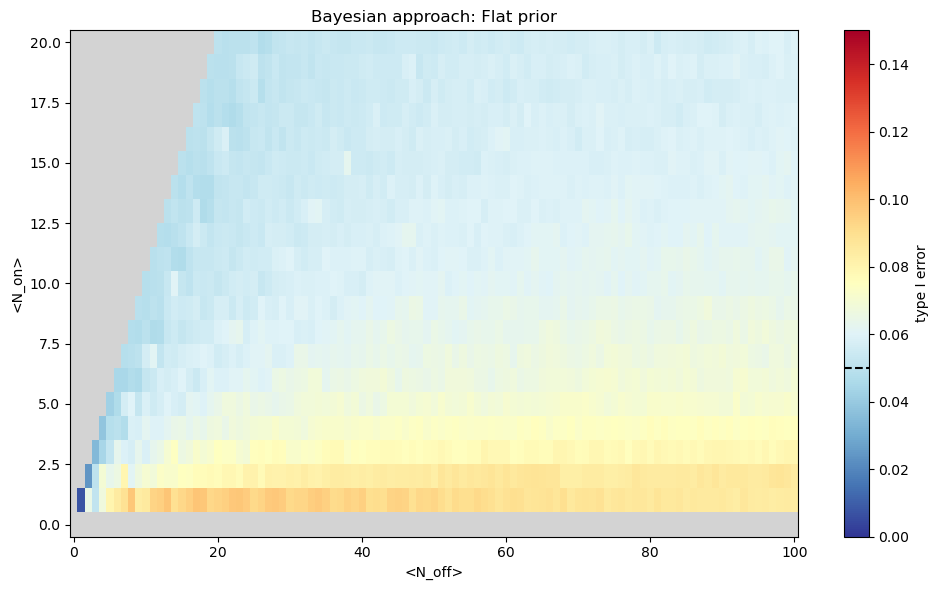

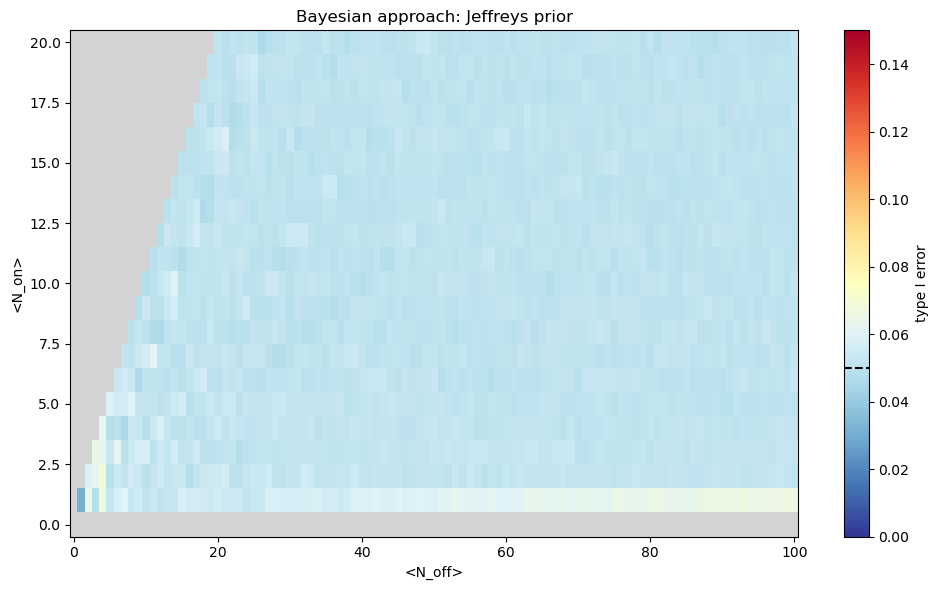

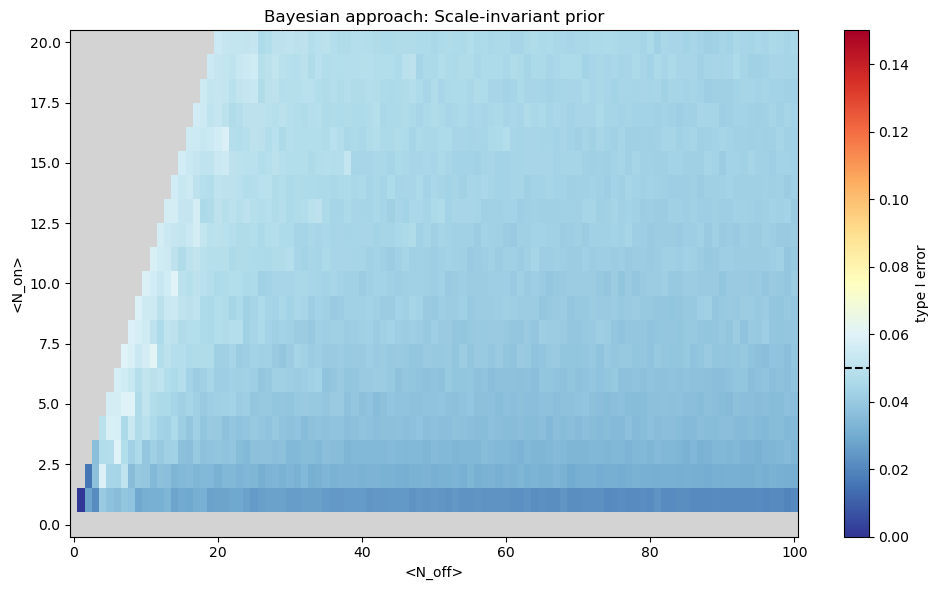

In [84]:
B_grid, Non_grid = np.meshgrid(lam, N_on)

cmap = plt.get_cmap('RdYlBu_r').copy()
cmap.set_bad('lightgrey')

for prior_name, error_matrix in (
    ('Flat prior', error_matrix_flat)
    ,('Jeffreys prior', error_matrix_jeffreys)
    ,('Scale-invariant prior', error_matrix_scale_invariant)
):
    fig, ax = plt.subplots(figsize=(10, 6))

    c = ax.pcolormesh(
        B_grid
        ,Non_grid
        ,error_matrix
        ,cmap=cmap
        ,shading='nearest'
        ,vmin=0, vmax=0.15
    )

    cbar = plt.colorbar(c, ax=ax, label='type I error')
    cbar.ax.axhline(0.05, color='black', lw=1.5, linestyle='--')

    ax.set_xlabel('<N_off>')
    ax.set_ylabel('<N_on>')
    ax.set_title(f'Bayesian approach: {prior_name}')

    plt.tight_layout()
    plt.show()

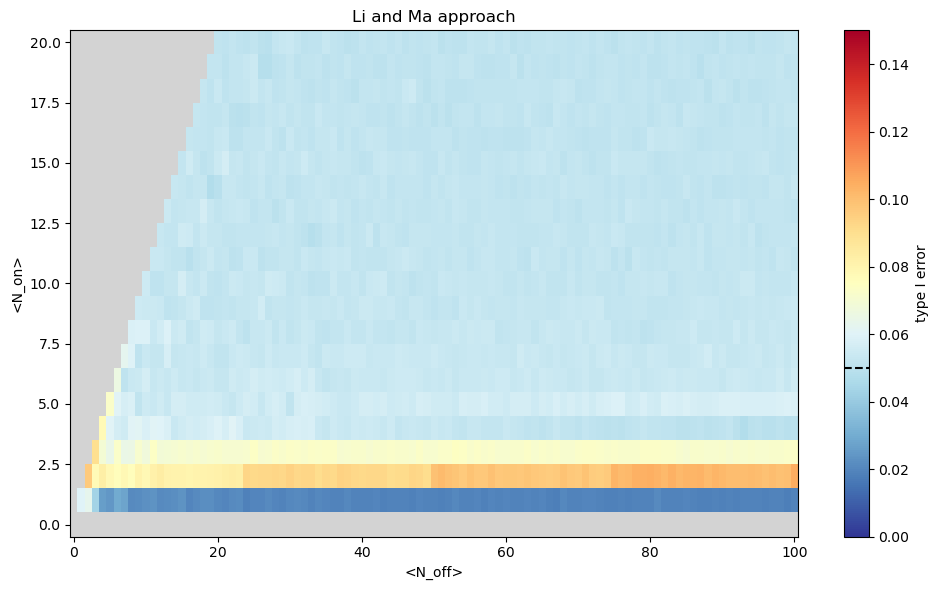

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))

B_grid, Non_grid = np.meshgrid(lam, N_on)

cmap = plt.get_cmap('RdYlBu_r').copy()
cmap.set_bad('lightgrey')

c = ax.pcolormesh(
    B_grid
    ,Non_grid
    ,error_matrix_W
    ,cmap=cmap
    ,shading='nearest'
    ,vmin=0, vmax=0.15
)

cbar = plt.colorbar(c, ax=ax, label='type I error')
cbar.ax.axhline(0.05, color='black', lw=1.5, linestyle='--')

ax.set_xlabel('<N_off>')
ax.set_ylabel('<N_on>')
ax.set_title('Li and Ma approach')

plt.tight_layout()
plt.show()

## Comparison of methods: type II error

### $\lambda = 2.5$

In [4]:
lam = 2.5

In [8]:
d = list(np.arange(0, 2.501, sep))
d_arr = np.array(d)

non = np.random.poisson(lam * (1 + d_arr[:, None]), (len(d), sample_value))
nof = np.random.poisson(lam * tau, (len(d), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

et_2_flat = list(1 - np.mean(p_flat > 0.95, axis=1))
et_2_jeffreys = list(1 - np.mean(p_jeffreys > 0.95, axis=1))
et_2_scale_invariant = list(1 - np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
et_2_W = list(1 - np.mean(p_value < 0.05, axis=1))

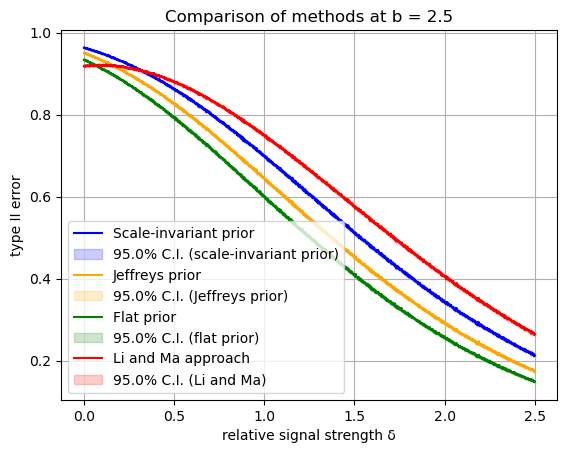

In [9]:
x = np.array(d)
flat = np.array(et_2_flat)
jeffreys = np.array(et_2_jeffreys)
bayes = np.array(et_2_scale_invariant)
wilks = np.array(et_2_W)

f_lower, f_upper = error_ci(flat, 0.05, sample_value)
j_lower, j_upper = error_ci(jeffreys, 0.05, sample_value)
b_lower, b_upper = error_ci(bayes, 0.05, sample_value)
w_lower, w_upper = error_ci(wilks, 0.05, sample_value)

plt.plot(x, bayes, color='blue', label="Scale-invariant prior")
plt.fill_between(x, b_lower, b_upper, color='blue', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (scale-invariant prior)')

plt.plot(x, jeffreys, color='orange', label="Jeffreys prior")
plt.fill_between(x, j_lower, j_upper, color='orange', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Jeffreys prior)')

plt.plot(x, flat, color='green', label="Flat prior")
plt.fill_between(x, f_lower, f_upper, color='green', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (flat prior)')

plt.plot(x, wilks, color='red', label="Li and Ma approach")
plt.fill_between(x, w_lower, w_upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Li and Ma)')

plt.xlabel('relative signal strength δ')
plt.ylabel('type II error')
plt.grid()
plt.title(f'Comparison of methods at b = {lam}')
plt.legend()
plt.show()

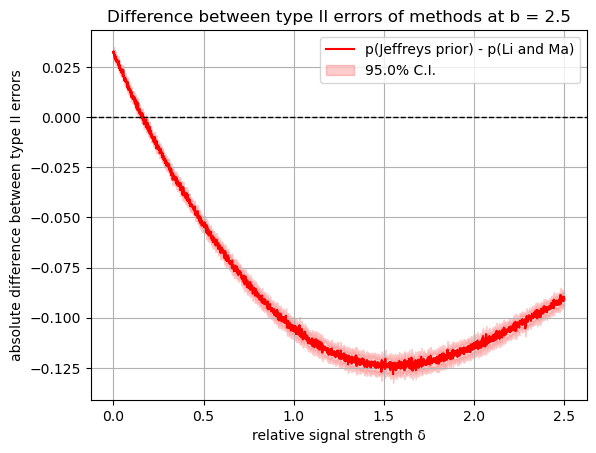

In [10]:
lower, delta, upper = delta_ci(wilks, jeffreys, 0.05, sample_value)

plt.plot(x, delta, color='red', label='p(Jeffreys prior) - p(Li and Ma)')
plt.fill_between(x, lower, upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I.')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('relative signal strength δ')
plt.ylabel('absolute difference between type II errors')
plt.grid()
plt.title(f'Difference between type II errors of methods at b = {lam}')
plt.legend()
plt.show()

### $\lambda = 10$

In [98]:
lam = 10

In [99]:
d = list(np.arange(0, 1.801, sep))
d_arr = np.array(d)

non = np.random.poisson(lam * (1 + d_arr[:, None]), (len(d), sample_value))
nof = np.random.poisson(lam * tau, (len(d), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

et_2_flat = list(1 - np.mean(p_flat > 0.95, axis=1))
et_2_jeffreys = list(1 - np.mean(p_jeffreys > 0.95, axis=1))
et_2_scale_invariant = list(1 - np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
et_2_W = list(1 - np.mean(p_value < 0.05, axis=1))

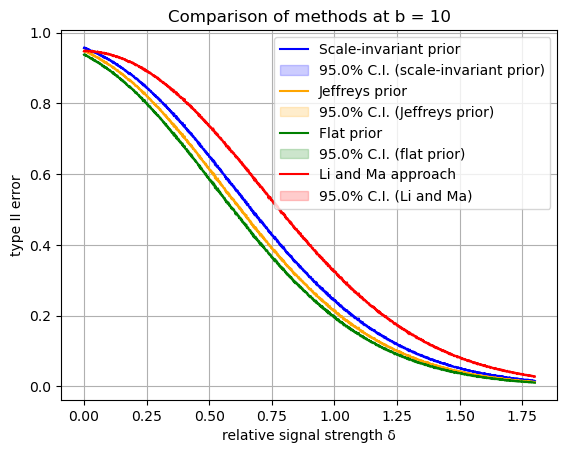

In [100]:
x = np.array(d)
flat = np.array(et_2_flat)
jeffreys = np.array(et_2_jeffreys)
bayes = np.array(et_2_scale_invariant)
wilks = np.array(et_2_W)

f_lower, f_upper = error_ci(flat, 0.05, sample_value)
j_lower, j_upper = error_ci(jeffreys, 0.05, sample_value)
b_lower, b_upper = error_ci(bayes, 0.05, sample_value)
w_lower, w_upper = error_ci(wilks, 0.05, sample_value)

plt.plot(x, bayes, color='blue', label="Scale-invariant prior")
plt.fill_between(x, b_lower, b_upper, color='blue', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (scale-invariant prior)')

plt.plot(x, jeffreys, color='orange', label="Jeffreys prior")
plt.fill_between(x, j_lower, j_upper, color='orange', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Jeffreys prior)')

plt.plot(x, flat, color='green', label="Flat prior")
plt.fill_between(x, f_lower, f_upper, color='green', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (flat prior)')

plt.plot(x, wilks, color='red', label="Li and Ma approach")
plt.fill_between(x, w_lower, w_upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Li and Ma)')

plt.xlabel('relative signal strength δ')
plt.ylabel('type II error')
plt.grid()
plt.title(f'Comparison of methods at b = {lam}')
plt.legend()
plt.show()

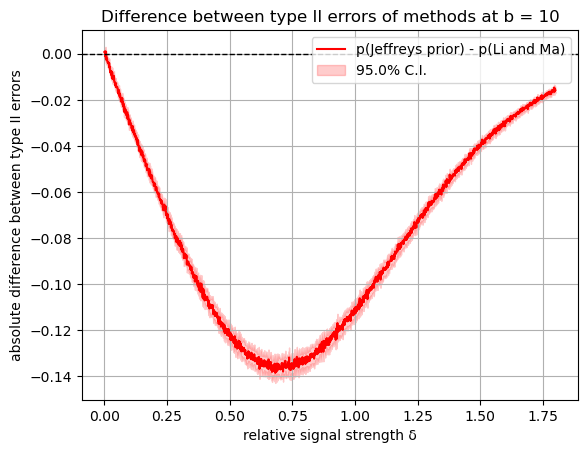

In [101]:
lower, delta, upper = delta_ci(wilks, jeffreys, 0.05, sample_value)

plt.plot(x, delta, color='red', label='p(Jeffreys prior) - p(Li and Ma)')
plt.fill_between(x, lower, upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I.')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('relative signal strength δ')
plt.ylabel('absolute difference between type II errors')
plt.grid()
plt.title(f'Difference between type II errors of methods at b = {lam}')
plt.legend()
plt.show()

### $\lambda = 40$

In [102]:
lam = 40

In [103]:
d = list(np.arange(0, 1.001, sep))
d_arr = np.array(d)

non = np.random.poisson(lam * (1 + d_arr[:, None]), (len(d), sample_value))
nof = np.random.poisson(lam * tau, (len(d), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

et_2_flat = list(1 - np.mean(p_flat > 0.95, axis=1))
et_2_jeffreys = list(1 - np.mean(p_jeffreys > 0.95, axis=1))
et_2_scale_invariant = list(1 - np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
et_2_W = list(1 - np.mean(p_value < 0.05, axis=1))

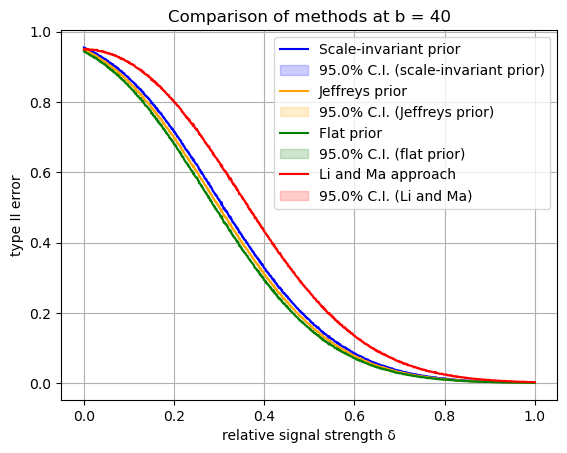

In [104]:
x = np.array(d)
flat = np.array(et_2_flat)
jeffreys = np.array(et_2_jeffreys)
bayes = np.array(et_2_scale_invariant)
wilks = np.array(et_2_W)

f_lower, f_upper = error_ci(flat, 0.05, sample_value)
j_lower, j_upper = error_ci(jeffreys, 0.05, sample_value)
b_lower, b_upper = error_ci(bayes, 0.05, sample_value)
w_lower, w_upper = error_ci(wilks, 0.05, sample_value)

plt.plot(x, bayes, color='blue', label="Scale-invariant prior")
plt.fill_between(x, b_lower, b_upper, color='blue', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (scale-invariant prior)')

plt.plot(x, jeffreys, color='orange', label="Jeffreys prior")
plt.fill_between(x, j_lower, j_upper, color='orange', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Jeffreys prior)')

plt.plot(x, flat, color='green', label="Flat prior")
plt.fill_between(x, f_lower, f_upper, color='green', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (flat prior)')

plt.plot(x, wilks, color='red', label="Li and Ma approach")
plt.fill_between(x, w_lower, w_upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Li and Ma)')

plt.xlabel('relative signal strength δ')
plt.ylabel('type II error')
plt.grid()
plt.title(f'Comparison of methods at b = {lam}')
plt.legend()
plt.show()

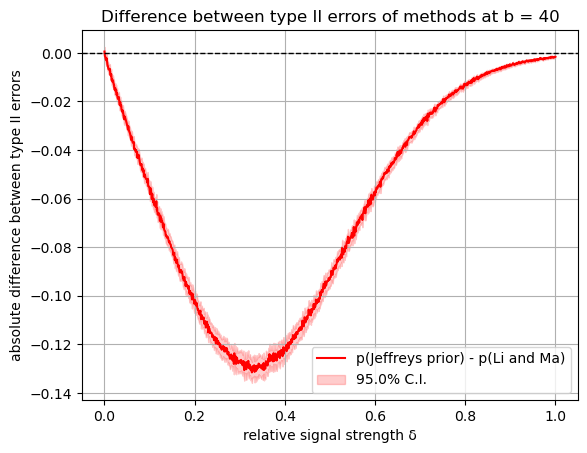

In [105]:
lower, delta, upper = delta_ci(wilks, jeffreys, 0.05, sample_value)

plt.plot(x, delta, color='red', label='p(Jeffreys prior) - p(Li and Ma)')
plt.fill_between(x, lower, upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I.')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('relative signal strength δ')
plt.ylabel('absolute difference between type II errors')
plt.grid()
plt.title(f'Difference between type II errors of methods at b = {lam}')
plt.legend()
plt.show()

### $\lambda = 200$

In [106]:
lam = 200

In [107]:
d = list(np.arange(0, 0.601, sep))
d_arr = np.array(d)

non = np.random.poisson(lam * (1 + d_arr[:, None]), (len(d), sample_value))
nof = np.random.poisson(lam * tau, (len(d), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

et_2_flat = list(1 - np.mean(p_flat > 0.95, axis=1))
et_2_jeffreys = list(1 - np.mean(p_jeffreys > 0.95, axis=1))
et_2_scale_invariant = list(1 - np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
et_2_W = list(1 - np.mean(p_value < 0.05, axis=1))

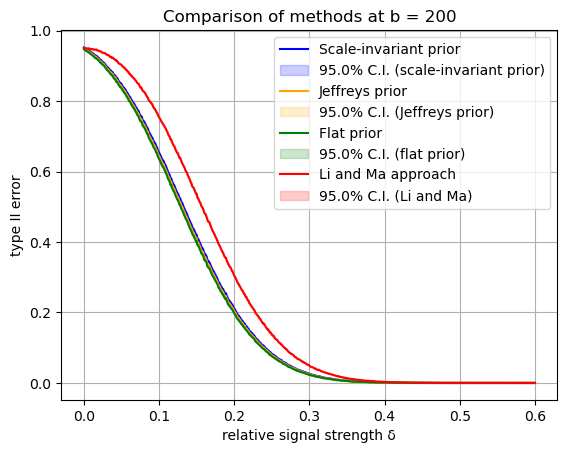

In [108]:
x = np.array(d)
flat = np.array(et_2_flat)
jeffreys = np.array(et_2_jeffreys)
bayes = np.array(et_2_scale_invariant)
wilks = np.array(et_2_W)

f_lower, f_upper = error_ci(flat, 0.05, sample_value)
j_lower, j_upper = error_ci(jeffreys, 0.05, sample_value)
b_lower, b_upper = error_ci(bayes, 0.05, sample_value)
w_lower, w_upper = error_ci(wilks, 0.05, sample_value)

plt.plot(x, bayes, color='blue', label="Scale-invariant prior")
plt.fill_between(x, b_lower, b_upper, color='blue', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (scale-invariant prior)')

plt.plot(x, jeffreys, color='orange', label="Jeffreys prior")
plt.fill_between(x, j_lower, j_upper, color='orange', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Jeffreys prior)')

plt.plot(x, flat, color='green', label="Flat prior")
plt.fill_between(x, f_lower, f_upper, color='green', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (flat prior)')

plt.plot(x, wilks, color='red', label="Li and Ma approach")
plt.fill_between(x, w_lower, w_upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Li and Ma)')

plt.xlabel('relative signal strength δ')
plt.ylabel('type II error')
plt.grid()
plt.title(f'Comparison of methods at b = {lam}')
plt.legend()
plt.show()

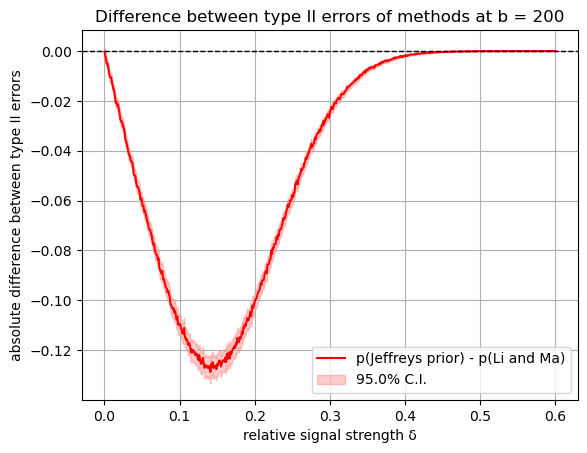

In [109]:
lower, delta, upper = delta_ci(wilks, jeffreys, 0.05, sample_value)

plt.plot(x, delta, color='red', label='p(Jeffreys prior) - p(Li and Ma)')
plt.fill_between(x, lower, upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I.')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('relative signal strength δ')
plt.ylabel('absolute difference between type II errors')
plt.grid()
plt.title(f'Difference between type II errors of methods at b = {lam}')
plt.legend()
plt.show()

### $\lambda = 2000$

In [110]:
lam = 2000

In [111]:
d = list(np.arange(0, 0.151, sep))
d_arr = np.array(d)

non = np.random.poisson(lam * (1 + d_arr[:, None]), (len(d), sample_value))
nof = np.random.poisson(lam * tau, (len(d), sample_value))

p_flat = pr_vect(non, nof, tau, sigma=0)
p_jeffreys = pr_vect(non, nof, tau, sigma=0.5)
p_scale_invariant = pr_vect(non, nof, tau, sigma=1)

et_2_flat = list(1 - np.mean(p_flat > 0.95, axis=1))
et_2_jeffreys = list(1 - np.mean(p_jeffreys > 0.95, axis=1))
et_2_scale_invariant = list(1 - np.mean(p_scale_invariant > 0.95, axis=1))

p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
et_2_W = list(1 - np.mean(p_value < 0.05, axis=1))

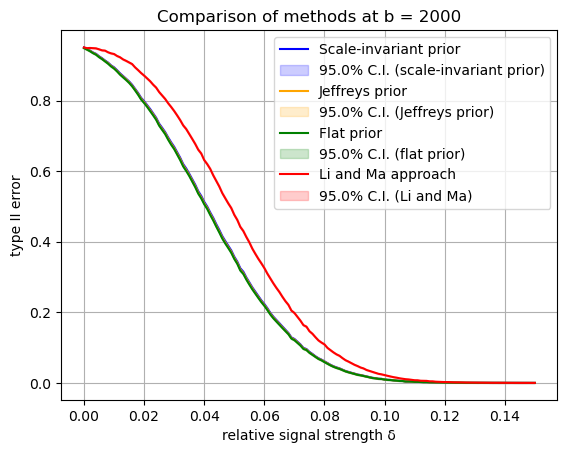

In [112]:
x = np.array(d)
flat = np.array(et_2_flat)
jeffreys = np.array(et_2_jeffreys)
bayes = np.array(et_2_scale_invariant)
wilks = np.array(et_2_W)

f_lower, f_upper = error_ci(flat, 0.05, sample_value)
j_lower, j_upper = error_ci(jeffreys, 0.05, sample_value)
b_lower, b_upper = error_ci(bayes, 0.05, sample_value)
w_lower, w_upper = error_ci(wilks, 0.05, sample_value)

plt.plot(x, bayes, color='blue', label="Scale-invariant prior")
plt.fill_between(x, b_lower, b_upper, color='blue', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (scale-invariant prior)')

plt.plot(x, jeffreys, color='orange', label="Jeffreys prior")
plt.fill_between(x, j_lower, j_upper, color='orange', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Jeffreys prior)')

plt.plot(x, flat, color='green', label="Flat prior")
plt.fill_between(x, f_lower, f_upper, color='green', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (flat prior)')

plt.plot(x, wilks, color='red', label="Li and Ma approach")
plt.fill_between(x, w_lower, w_upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I. (Li and Ma)')

plt.xlabel('relative signal strength δ')
plt.ylabel('type II error')
plt.grid()
plt.title(f'Comparison of methods at b = {lam}')
plt.legend()
plt.show()

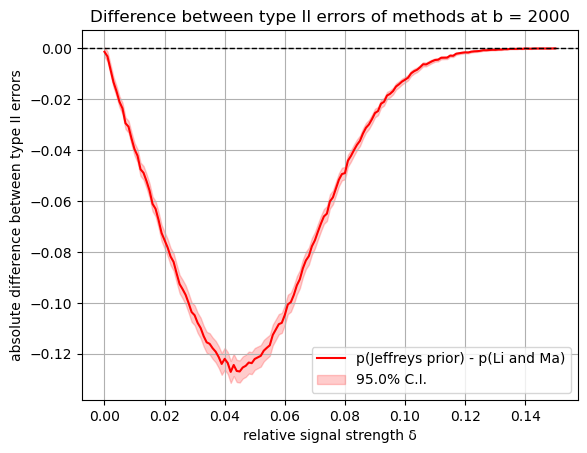

In [113]:
lower, delta, upper = delta_ci(wilks, jeffreys, 0.05, sample_value)

plt.plot(x, delta, color='red', label='p(Jeffreys prior) - p(Li and Ma)')
plt.fill_between(x, lower, upper, color='red', alpha = 0.2, label=f'{round((1 - 0.05) * 100, 1)}% C.I.')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('relative signal strength δ')
plt.ylabel('absolute difference between type II errors')
plt.grid()
plt.title(f'Difference between type II errors of methods at b = {lam}')
plt.legend()
plt.show()

## Methods robustness for overdispersion

Distributions significantly differ: statistic=0.1356, p-value=0.0000


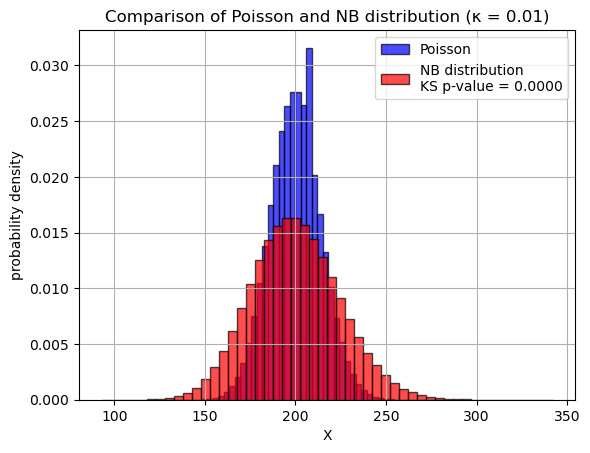

In [19]:
theta = 1e-2
sample_size = 10000000

pois = np.random.poisson(200, sample_size)
pois_ = pois_with_overdispersion(200, theta, sample_size)

ks_stat, ks_p = stats.ks_2samp(pois, pois_)

if ks_p > 0.05:
    print(f'Distributions coincide: statistic={ks_stat:.4f}, p-value={ks_p:.4f}')
else:
    print(f'Distributions significantly differ: statistic={ks_stat:.4f}, p-value={ks_p:.4f}')

plt.hist(pois, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='Poisson')

plt.hist(pois_, bins=50, density=True, alpha=0.7, color='red', edgecolor='black', label=f'NB distribution\nKS p-value = {ks_p:.4f}')

plt.xlabel('X')
plt.ylabel('probability density')
plt.grid()
plt.legend()
plt.title(f'Comparison of Poisson and NB distribution (κ = {theta})')
plt.show()

In [16]:
theta = [0, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1, 1]

error_type_1 = {prior_name: [] for prior_name in prior_sigmas}
error_type_1_W = []

for k in tqdm(theta, desc='Calculation of Type I Error'):

    non = pois_with_overdispersion(200, k, sample_value)
    nof = pois_with_overdispersion(200 * tau, k, sample_value)

    for prior_name, sigma in prior_sigmas.items():
        p = pr_vect(non, nof, tau, sigma)
        error_type_1[prior_name].append(np.mean(p > 0.95))

    p_value = 1 - stats.chi2.cdf(S(non, nof, tau), df=1)
    error_type_1_W.append(np.mean(p_value < 0.05))

Calculation of Type I Error: 100%|██████████████████████████████████████████████████████| 11/11 [00:01<00:00, 10.25it/s]


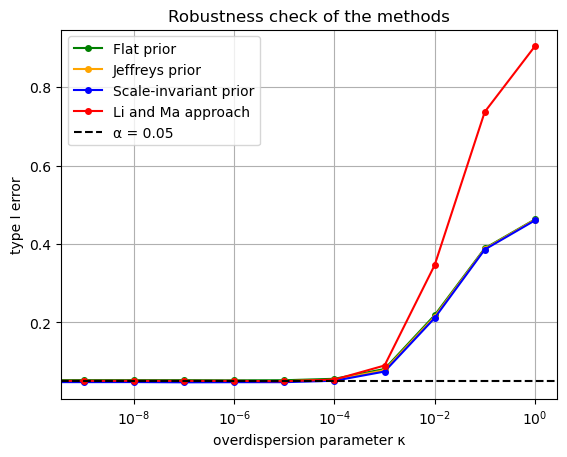

In [18]:
x = np.array(theta)

for prior_name, error_type_1_prior in error_type_1.items():
    y = np.array(error_type_1_prior)
    plt.semilogx(x, y, marker='o', linestyle='-', label=prior_name, markersize=4, color=prior_colors[prior_name])

plt.semilogx(x, np.array(error_type_1_W), marker='o', linestyle='-', label='Li and Ma approach', markersize=4, color='red')
plt.axhline(y=0.05, label='α = 0.05', color='black', linestyle='--')

plt.xlabel('overdispersion parameter κ')
plt.ylabel('type I error')
plt.grid()
plt.title('Robustness check of the methods')
plt.legend()
plt.show()